# Importing required dependencies

In [23]:
import torch 

import torch.nn as nn

import torch.optim as optim

import nltk

import regex as re

import pandas as pd

import numpy as np



from matplotlib import pyplot as plt

from nltk.corpus import stopwords

from torch.utils.data import DataLoader, Dataset

from collections import Counter

import torch.nn.functional as F

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns

# ANFIS implementation

Code taken from: https://github.com/jfpower/anfis-pytorch/blob/master/anfis.py

In [24]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
'''
    ANFIS in torch: the ANFIS layers
    @author: James Power <james.power@mu.ie> Apr 12 18:13:10 2019
    Acknowledgement: twmeggs' implementation of ANFIS in Python was very
    useful in understanding how the ANFIS structures could be interpreted:
        https://github.com/twmeggs/anfis
'''

import itertools
from collections import OrderedDict


dtype = torch.float


class FuzzifyVariable(torch.nn.Module):
    '''
        Represents a single fuzzy variable, holds a list of its MFs.
        Forward pass will then fuzzify the input (value for each MF).
    '''
    def __init__(self, mfdefs):
        super(FuzzifyVariable, self).__init__()
        if isinstance(mfdefs, list):  # No MF names supplied
            mfnames = ['mf{}'.format(i) for i in range(len(mfdefs))]
            mfdefs = OrderedDict(zip(mfnames, mfdefs))
        self.mfdefs = torch.nn.ModuleDict(mfdefs)
        self.padding = 0

    @property
    def num_mfs(self):
        '''Return the actual number of MFs (ignoring any padding)'''
        return len(self.mfdefs)

    def members(self):
        '''
            Return an iterator over this variables's membership functions.
            Yields tuples of the form (mf-name, MembFunc-object)
        '''
        return self.mfdefs.items()

    def pad_to(self, new_size):
        '''
            Will pad result of forward-pass (with zeros) so it has new_size,
            i.e. as if it had new_size MFs.
        '''
        self.padding = new_size - len(self.mfdefs)

    def fuzzify(self, x):
        '''
            Yield a list of (mf-name, fuzzy values) for these input values.
        '''
        for mfname, mfdef in self.mfdefs.items():
            yvals = mfdef(x)
            yield(mfname, yvals)

    def forward(self, x):
        '''
            Return a tensor giving the membership value for each MF.
            x.shape: n_cases
            y.shape: n_cases * n_mfs
        '''
        y_pred = torch.cat([mf(x) for mf in self.mfdefs.values()], dim=1)
        if self.padding > 0:
            y_pred = torch.cat([y_pred,
                                torch.zeros(x.shape[0], self.padding)], dim=1)
        return y_pred


class FuzzifyLayer(torch.nn.Module):
    '''
        A list of fuzzy variables, representing the inputs to the FIS.
        Forward pass will fuzzify each variable individually.
        We pad the variables so they all seem to have the same number of MFs,
        as this allows us to put all results in the same tensor.
    '''
    def __init__(self, varmfs, varnames=None):
        super(FuzzifyLayer, self).__init__()
        if not varnames:
            self.varnames = ['x{}'.format(i) for i in range(len(varmfs))]
        else:
            self.varnames = list(varnames)
        maxmfs = max([var.num_mfs for var in varmfs])
        for var in varmfs:
            var.pad_to(maxmfs)
        self.varmfs = torch.nn.ModuleDict(zip(self.varnames, varmfs))

    @property
    def num_in(self):
        '''Return the number of input variables'''
        return len(self.varmfs)

    @property
    def max_mfs(self):
        ''' Return the max number of MFs in any variable'''
        return max([var.num_mfs for var in self.varmfs.values()])

    def __repr__(self):
        '''
            Print the variables, MFS and their parameters (for info only)
        '''
        r = ['Input variables']
        for varname, members in self.varmfs.items():
            r.append('Variable {}'.format(varname))
            for mfname, mfdef in members.mfdefs.items():
                r.append('- {}: {}({})'.format(mfname,
                         mfdef.__class__.__name__,
                         ', '.join(['{}={}'.format(n, p.item())
                                   for n, p in mfdef.named_parameters()])))
        return '\n'.join(r)

    def forward(self, x):
        ''' Fuzzyify each variable's value using each of its corresponding mfs.
            x.shape = n_cases * n_in
            y.shape = n_cases * n_in * n_mfs
        '''
        assert x.shape[1] == self.num_in,\
            '{} is wrong no. of input values'.format(self.num_in)
        y_pred = torch.stack([var(x[:, i:i+1])
                              for i, var in enumerate(self.varmfs.values())],
                             dim=1)
        return y_pred


class AntecedentLayer(torch.nn.Module):
    '''
        Form the 'rules' by taking all possible combinations of the MFs
        for each variable. Forward pass then calculates the fire-strengths.
    '''
    def __init__(self, varlist):
        super(AntecedentLayer, self).__init__()
        # Count the (actual) mfs for each variable:
        mf_count = [var.num_mfs for var in varlist]
        # Now make the MF indices for each rule:
        mf_indices = itertools.product(*[range(n) for n in mf_count])
        self.mf_indices = torch.tensor(list(mf_indices))
        # mf_indices.shape is n_rules * n_in

    def num_rules(self):
        return len(self.mf_indices)

    def extra_repr(self, varlist=None):
        if not varlist:
            return None
        row_ants = []
        mf_count = [len(fv.mfdefs) for fv in varlist.values()]
        for rule_idx in itertools.product(*[range(n) for n in mf_count]):
            thisrule = []
            for (varname, fv), i in zip(varlist.items(), rule_idx):
                thisrule.append('{} is {}'
                                .format(varname, list(fv.mfdefs.keys())[i]))
            row_ants.append(' and '.join(thisrule))
        return '\n'.join(row_ants)

    def forward(self, x):
        ''' Calculate the fire-strength for (the antecedent of) each rule
            x.shape = n_cases * n_in * n_mfs
            y.shape = n_cases * n_rules
        '''
        # Expand (repeat) the rule indices to equal the batch size:
        batch_indices = self.mf_indices.expand((x.shape[0], -1, -1))
        batch_indices = batch_indices.to("cuda" if torch.cuda.is_available() else "cpu")
        # Then use these indices to populate the rule-antecedents
        ants = torch.gather(x.transpose(1, 2), 1, batch_indices)
        # ants.shape is n_cases * n_rules * n_in
        # Last, take the AND (= product) for each rule-antecedent
        rules = torch.prod(ants, dim=2)
        return rules


class ConsequentLayer(torch.nn.Module):
    '''
        A simple linear layer to represent the TSK consequents.
        Hybrid learning, so use MSE (not BP) to adjust coefficients.
        Hence, coeffs are no longer parameters for backprop.
    '''
    def __init__(self, d_in, d_rule, d_out):
        super(ConsequentLayer, self).__init__()
        c_shape = torch.Size([d_rule, d_out, d_in+1])
        self.classes = d_out
        self._coeff = torch.zeros(c_shape, dtype=dtype, requires_grad=True).to("cuda" if torch.cuda.is_available() else "cpu")

    @property
    def coeff(self):
        '''
            Record the (current) coefficients for all the rules
            coeff.shape: n_rules * n_out * (n_in+1)
        '''
        return self._coeff

    @coeff.setter
    def coeff(self, new_coeff):
        '''
            Record new coefficients for all the rules
            coeff: for each rule, for each output variable:
                   a coefficient for each input variable, plus a constant
        '''
        assert new_coeff.shape == self.coeff.shape, \
            'Coeff shape should be {}, but is actually {}'\
            .format(self.coeff.shape, new_coeff.shape)
        self._coeff = new_coeff

    def fit_coeff(self, x, weights, y_actual):
        '''
            Use LSE to solve for coeff: y_actual = coeff * (weighted)x
                  x.shape: n_cases * n_in
            weights.shape: n_cases * n_rules
            [ coeff.shape: n_rules * n_out * (n_in+1) ]
                  y.shape: n_cases * n_out
        '''
        # Append 1 to each list of input vals, for the constant term:
        ones_matrix = torch.ones(x.shape[0], 1)
        ones_matrix = ones_matrix.to("cuda" if torch.cuda.is_available() else "cpu")
        x_plus = torch.cat([x, ones_matrix], dim=1)
        # Shape of weighted_x is n_cases * n_rules * (n_in+1)
        weighted_x = torch.einsum('bp, bq -> bpq', weights, x_plus)
        # Can't have value 0 for weights, or LSE won't work:
        weighted_x[weighted_x == 0] = 1e-12
        # Squash x and y down to 2D matrices for gels:
        weighted_x_2d = weighted_x.view(weighted_x.shape[0], -1)
        y_actual = F.one_hot(y_actual, num_classes=self.classes).float()
        y_actual_2d = y_actual.view(y_actual.shape[0], -1)
        # Use gels to do LSE, then pick out the solution rows:
        try:
            coeff_2d, residuals, rank, singular_values = torch.linalg.lstsq(weighted_x_2d.float(), y_actual_2d.float())
            # coeff_2d, _ = torch.linalg.lstsq(y_actual_2d.float(), weighted_x_2d.float())
        except RuntimeError as e:
            print('Internal error in gels', e)
            print('Weights are:', weighted_x)
            raise e
        coeff_2d = coeff_2d[0:weighted_x_2d.shape[1]]
        # Reshape to 3D tensor: divide by rules, n_in+1, then swap last 2 dims
        self.coeff = coeff_2d.view(weights.shape[1], x.shape[1]+1, -1)\
            .transpose(1, 2)
        # coeff dim is thus: n_rules * n_out * (n_in+1)

    def forward(self, x):
        '''
            Calculate: y = coeff * x + const   [NB: no weights yet]
                  x.shape: n_cases * n_in
              coeff.shape: n_rules * n_out * (n_in+1)
                  y.shape: n_cases * n_out * n_rules
        '''
        # Append 1 to each list of input vals, for the constant term:
        ones_matrix = torch.ones(x.shape[0], 1)
        ones_matrix = ones_matrix.to("cuda" if torch.cuda.is_available() else "cpu")
        x_plus = torch.cat([x, ones_matrix], dim=1)
        # x_plus = torch.cat([x, torch.ones(x.shape[0], 1)], dim=1)
        # Need to switch dimansion for the multipy, then switch back:
        y_pred = torch.matmul(self.coeff, x_plus.t())
        return y_pred.transpose(0, 2)  # swaps cases and rules


class PlainConsequentLayer(ConsequentLayer):
    '''
        A linear layer to represent the TSK consequents.
        Not hybrid learning, so coefficients are backprop-learnable parameters.
    '''
    def __init__(self, *params):
        super(PlainConsequentLayer, self).__init__(*params)
        self.register_parameter('coefficients',
                                torch.nn.Parameter(self._coeff))

    @property
    def coeff(self):
        '''
            Record the (current) coefficients for all the rules
            coeff.shape: n_rules * n_out * (n_in+1)
        '''
        return self.coefficients

    def fit_coeff(self, x, weights, y_actual):
        '''
        '''
        assert False,\
            'Not hybrid learning: I\'m using BP to learn coefficients'


class WeightedSumLayer(torch.nn.Module):
    '''
        Sum the TSK for each outvar over rules, weighted by fire strengths.
        This could/should be layer 5 of the Anfis net.
        I don't actually use this class, since it's just one line of code.
    '''
    def __init__(self):
        super(WeightedSumLayer, self).__init__()

    def forward(self, weights, tsk):
        '''
            weights.shape: n_cases * n_rules
                tsk.shape: n_cases * n_out * n_rules
             y_pred.shape: n_cases * n_out
        '''
        # Add a dimension to weights to get the bmm to work:
        y_pred = torch.bmm(tsk, weights.unsqueeze(2))
        return y_pred.squeeze(2)


class AnfisNet(torch.nn.Module):
    '''
        This is a container for the 5 layers of the ANFIS net.
        The forward pass maps inputs to outputs based on current settings,
        and then fit_coeff will adjust the TSK coeff using LSE.
    '''
    def __init__(self, description, invardefs, outvarnames, hybrid=True):
        super(AnfisNet, self).__init__()
        self.description = description
        self.outvarnames = outvarnames
        self.hybrid = hybrid
        varnames = [v for v, _ in invardefs]
        mfdefs = [FuzzifyVariable(mfs) for _, mfs in invardefs]
        self.num_in = len(invardefs)
        self.num_rules = np.prod([len(mfs) for _, mfs in invardefs])
        if self.hybrid:
            cl = ConsequentLayer(self.num_in, self.num_rules, self.num_out)
        else:
            cl = PlainConsequentLayer(self.num_in, self.num_rules, self.num_out)
        self.layer = torch.nn.ModuleDict(OrderedDict([
            ('fuzzify', FuzzifyLayer(mfdefs, varnames)),
            ('rules', AntecedentLayer(mfdefs)),
            # normalisation layer is just implemented as a function.
            ('consequent', cl),
            # weighted-sum layer is just implemented as a function.
            ]))

    @property
    def num_out(self):
        return len(self.outvarnames)

    @property
    def coeff(self):
        return self.layer['consequent'].coeff

    @coeff.setter
    def coeff(self, new_coeff):
        self.layer['consequent'].coeff = new_coeff

    def fit_coeff(self, x, y_actual):
        '''
            Do a forward pass (to get weights), then fit to y_actual.
            Does nothing for a non-hybrid ANFIS, so we have same interface.
        '''
        if self.hybrid:
            self(x)
            self.layer['consequent'].fit_coeff(x, self.weights, y_actual)

    def input_variables(self):
        '''
            Return an iterator over this system's input variables.
            Yields tuples of the form (var-name, FuzzifyVariable-object)
        '''
        return self.layer['fuzzify'].varmfs.items()

    def output_variables(self):
        '''
            Return an list of the names of the system's output variables.
        '''
        return self.outvarnames

    def extra_repr(self):
        rstr = []
        vardefs = self.layer['fuzzify'].varmfs
        rule_ants = self.layer['rules'].extra_repr(vardefs).split('\n')
        for i, crow in enumerate(self.layer['consequent'].coeff):
            rstr.append('Rule {:2d}: IF {}'.format(i, rule_ants[i]))
            rstr.append(' '*9+'THEN {}'.format(crow.tolist()))
        return '\n'.join(rstr)

    def forward(self, x):
        '''
            Forward pass: run x thru the five layers and return the y values.
            I save the outputs from each layer to an instance variable,
            as this might be useful for comprehension/debugging.
        '''
        self.fuzzified = self.layer['fuzzify'](x)
        self.raw_weights = self.layer['rules'](self.fuzzified)
        self.weights = F.normalize(self.raw_weights, p=1, dim=1)
        self.rule_tsk = self.layer['consequent'](x)
        # y_pred = self.layer['weighted_sum'](self.weights, self.rule_tsk)
        y_pred = torch.bmm(self.rule_tsk, self.weights.unsqueeze(2))
        self.y_pred = y_pred.squeeze(2)
        return self.y_pred


# These hooks are handy for debugging:

def module_hook(label):
    ''' Use this module hook like this:
        m = AnfisNet()
        m.layer.fuzzify.register_backward_hook(module_hook('fuzzify'))
        m.layer.consequent.register_backward_hook(modul_hook('consequent'))
    '''
    return (lambda module, grad_input, grad_output:
            print('BP for module', label,
                  'with out grad:', grad_output,
                  'and in grad:', grad_input))


def tensor_hook(label):
    '''
        If you want something more fine-graned, attach this to a tensor.
    '''
    return (lambda grad:
            print('BP for', label, 'with grad:', grad))

# Memberships function

Code taken from: https://github.com/jfpower/anfis-pytorch/blob/master/membership.py

In [25]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
    ANFIS in torch: some fuzzy membership functions.
    @author: James Power <james.power@mu.ie> Apr 12 18:13:10 2019
"""

import torch


def _mk_param(val):
    '''Make a torch parameter from a scalar value'''
    if isinstance(val, torch.Tensor):
        val = val.item()
    return torch.nn.Parameter(torch.tensor(val, dtype=torch.float))


class GaussMembFunc(torch.nn.Module):
    '''
        Gaussian membership functions, defined by two parameters:
            mu, the mean (center)
            sigma, the standard deviation.
    '''
    def __init__(self, mu, sigma):
        super(GaussMembFunc, self).__init__()
        self.register_parameter('mu', _mk_param(mu))
        self.register_parameter('sigma', _mk_param(sigma))

    def forward(self, x):
        val = torch.exp(-torch.pow(x - self.mu, 2) / (2 * self.sigma**2))
        return val

    def pretty(self):
        return 'GaussMembFunc {} {}'.format(self.mu, self.sigma)


def make_gauss_mfs(sigma, mu_list):
    '''Return a list of gaussian mfs, same sigma, list of means'''
    return [GaussMembFunc(mu, sigma) for mu in mu_list]


# Make the classes available via (controlled) reflection:
# get_class_for = {n: globals()[n]
#                  for n in ['BellMembFunc',
#                            'GaussMembFunc',
#                            'TriangularMembFunc',
#                            'TrapezoidalMembFunc',
#                            ]}


def make_anfis(in_features, num_mfs=5, num_out=1, hybrid=True):
    '''
        Make an ANFIS model, auto-calculating the (Gaussian) MFs.
        I need the x-vals to calculate a range and spread for the MFs.
        Variables get named x0, x1, x2,... and y0, y1, y2 etc.
    '''
    invars = []
    for i in range(in_features):
        sigma = 2.0 / num_mfs
        mulist = torch.linspace(-1.0, 1.0, num_mfs).tolist()
        invars.append(('x{}'.format(i), make_gauss_mfs(sigma, mulist)))
    outvars = ['y{}'.format(i) for i in range(num_out)]
    model = AnfisNet('Simple classifier', invars, outvars, hybrid=hybrid)
    return model

# Data import and label processing

In [26]:
df = pd.read_csv("/kaggle/input/datasets/alitaqishah/ai-vs-human-text-classification-dataset-2026/ai_vs_human_text_2026.csv")

df = df[["text_content", "label"]]

df["label"] = df["label"].map({"ai": 1, "human": 0})

# Data cleaning processes

In [27]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
def clean_data(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    words = [w for w in text.split() if w not in stop_words]

    return " ".join(words)

In [29]:
df["text_content"] = df["text_content"].apply(clean_data)

# Tokenization and encoding functions

In [30]:
def tokenize(text):

    return text.split()



train_texts = df["text_content"]

all_tokens = [token for text in train_texts for token in tokenize(text)]

vocab = {word: i+2 for i, word in enumerate(Counter(all_tokens))} # start from 2

vocab["<PAD>"] = 0

vocab["<UNK>"] = 1

In [31]:
def encode(text, max_len=52):

        tokens = tokenize(text)

        ids = [vocab.get(t, 1) for t in tokens]

        if len(ids) < max_len:

                ids += [0] * (max_len - len(ids))

        else:

                ids = ids[:max_len]

        return ids

# Creating data pipeline

In [32]:
class TextDataset(Dataset):

        def __init__(self, texts, labels):

                self.texts = [torch.tensor(encode(t), dtype=torch.long) for t in texts]

                self.labels = torch.tensor(labels, dtype=torch.float32)



        def __len__(self):

                return len(self.texts)



        def __getitem__(self, idx):

                return self.texts[idx], self.labels[idx]

# Setting up data pipeline

In [33]:
x = df["text_content"].values
y = df["label"].to_numpy(copy=True)

In [34]:
x_train, x_val, y_train, y_val = train_test_split(x, y, random_state=42, test_size=0.3)
x_val, x_test, y_val, y_test = train_test_split(x_val, y_val, random_state=42, test_size=0.5)

train_ds = TextDataset(x_train, y_train)

val_ds = TextDataset(x_val, y_val)



train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

val_dl = DataLoader(val_ds, batch_size=32)

# Custom MHA design

In [35]:
import math

class MHA(nn.Module):
    def __init__(self, d_model, red_size, num_heads, out_classes):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(in_features=d_model, out_features=d_model)
        self.k_proj = nn.Linear(in_features=d_model, out_features=d_model)
        self.v_proj = nn.Linear(in_features=d_model, out_features=d_model)
        self.red = nn.Linear(in_features=d_model, out_features=red_size)
        self.out_proj = make_anfis(red_size, 3, out_classes, False)

    def forward(self, x):
        batch_size = x.size(0)
        seq_length = x.size(1)
        
        # Project queries, keys, and values
        q = self.q_proj(x)
        k = self.k_proj(x).transpose(0, 1)
        v = self.v_proj(x)
        
        # Compute attention scores, optionally add attention mask to the score
        
        scores = torch.matmul(q, k) / math.sqrt(self.head_dim)
        attn_weights = F.softmax(scores, dim=-1)
        # optional: attn_weights = F.dropout(attn_weights, p=0.2)
        
        # Apply attention weights to values
        context = torch.matmul(attn_weights, v)
        context = context.contiguous()

        pooled = self.red(context)
        
        return self.out_proj(pooled), pooled

# LAHT design

In [36]:
class LAHT(nn.Module):

    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, num_heads = 8, red_size=5, out_size=2):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)

        self.mha = MHA(d_model=embed_dim, red_size=red_size, num_heads=num_heads, out_classes=out_size)



    def forward(self, x):
    
        x = self.embedding(x)

        _, (hidden, _) = self.lstm(x)

        x, pred_anfis = self.mha(hidden[-1])
    
        return F.softmax(x, dim=1), pred_anfis

# LAHT - Reverse design

In [37]:
class LAHTRev(nn.Module):

    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, num_heads = 8, red_size=5, out_size=2):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)

        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)

        self.fc = nn.Linear(in_features=hidden_dim, out_features=red_size)

        self.anfis = make_anfis(red_size, 3, out_classes, False)



    def forward(self, x):
    
        x = self.embedding(x)

        attn_output, attn_output_weights = self.mha(x, x, x)

        _, (hidden, _) = self.lstm(attn_output)

        pred_anfis = self.fc(hidden[-1])

        x = self.anfis(pred_anfis)
    
        return F.softmax(x, dim=1), pred_anfis

In [38]:
vocab_size = len(vocab)
embed_dim = 64
hidden_dim = 64
num_heads = 8
red_size = 5
out_classes = 2
epochs = 10

# LAHT Training

## LAHT training environment

In [39]:
model = LAHT(vocab_size, embed_dim, hidden_dim, num_heads, red_size, out_classes)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

## LAHT training log

Epoch 1 train loss 0.02106568843126297 acc 0.6764285714285714 val loss 0.02146961510181427 acc 0.6566666666666666
Epoch 2 train loss 0.019962153264454434 acc 0.6764285714285714 val loss 0.021073080201943716 acc 0.6566666666666666
Epoch 3 train loss 0.019789247810840606 acc 0.6764285714285714 val loss 0.02107003837823868 acc 0.6566666666666666
Epoch 4 train loss 0.019783128244536263 acc 0.6764285714285714 val loss 0.02106979638338089 acc 0.6566666666666666
Epoch 5 train loss 0.019804832360574176 acc 0.6764285714285714 val loss 0.021070230503877005 acc 0.6566666666666666
Epoch 6 train loss 0.01980869403907231 acc 0.6764285714285714 val loss 0.021074924767017365 acc 0.6566666666666666
Epoch 7 train loss 0.019788151915584293 acc 0.6764285714285714 val loss 0.02107057124376297 acc 0.6566666666666666
Epoch 8 train loss 0.019815416442496438 acc 0.6764285714285714 val loss 0.02107273797194163 acc 0.6566666666666666
Epoch 9 train loss 0.019814430049487523 acc 0.6764285714285714 val loss 0.02107

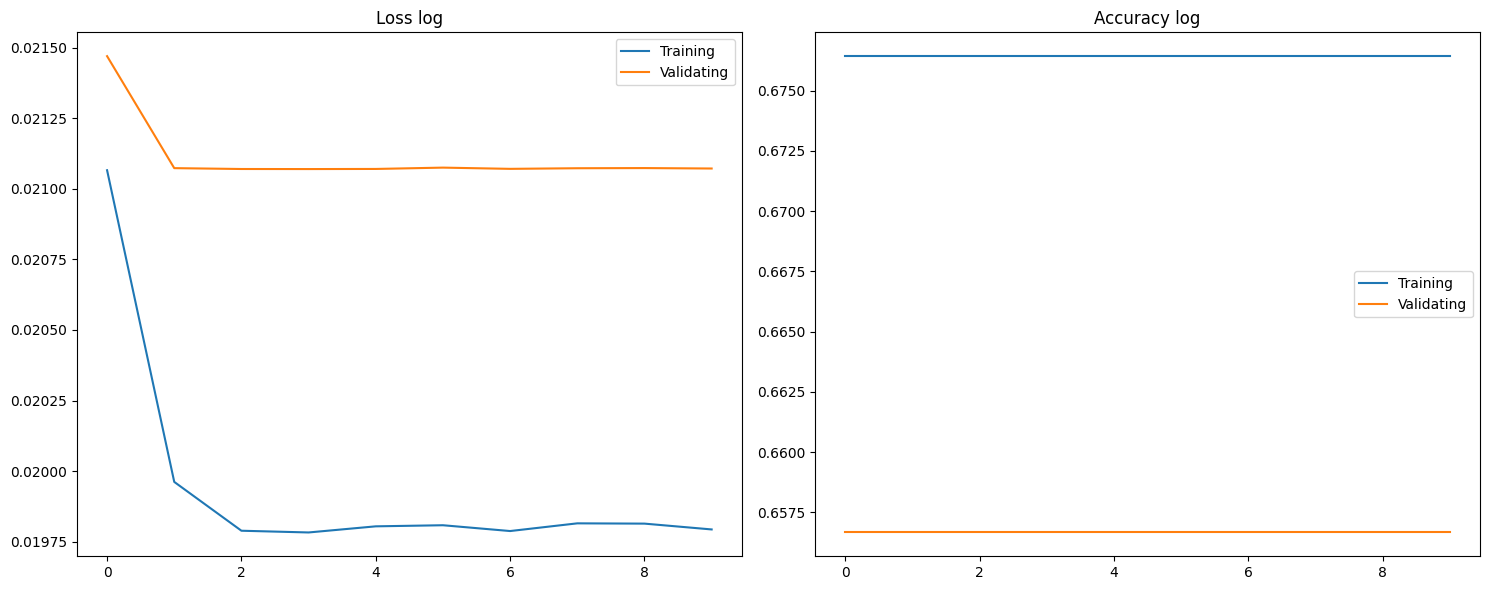

In [40]:
torch.save(model.state_dict(), "best_model.pt")

# best_model = deepcopy(model)
best_acc = 0

train_loss = []
train_acc = []
val_loss = []
val_acc = []

for i in range(1, epochs+1):
    model.train()

    diff = 0
    acc = 0
    total = 0

    preds = []
    outs = []

    for data, target in train_dl:
        optimizer.zero_grad()
        if torch.cuda.is_available():
            data, target = data.cuda(), target.cuda()

        out, pred_anfis = model(data)
        preds += [pred_anfis]
        outs += [target]
        loss = criterion(out, target.type(torch.int64))
        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)

        loss.backward()
        optimizer.step()

    train_loss += [diff/total]
    train_acc += [acc/total]

    model.eval()

    diff = 0
    acc = 0
    total = 0

    with torch.no_grad():
        
        x_pred = torch.cat(preds)
        x_pred = x_pred.to(device)
        y_acc = torch.cat(outs).to(device)
        model.mha.out_proj.fit_coeff(x_pred, y_acc)
        
        for data, target in val_dl:
            optimizer.zero_grad()
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()

            out, _ = model(data)
            loss = criterion(out, target.type(torch.int64))
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)

    val_loss += [diff/total]
    val_acc += [acc/total]

    if val_acc[-1] >= best_acc:
        best_acc = val_acc[-1]
        torch.save(model.state_dict(), "best_model.pt")

    # scheduler.step()

    print("Epoch {} train loss {} acc {} val loss {} acc {}".format(i, train_loss[-1], train_acc[-1],
                                                                   val_loss[-1], val_acc[-1]))

fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

index = 0

axes[index].plot(train_loss, label="Training")
axes[index].plot(val_loss, label="Validating")
axes[index].set_title("Loss log")
axes[index].legend()

index += 1

axes[index].plot(train_acc, label="Training")
axes[index].plot(val_acc, label="Validating")
axes[index].set_title("Accuracy log")
axes[index].legend()
plt.tight_layout()
plt.show()

## LATH testing result

              precision    recall  f1-score   support

           0       1.00      0.63      0.78       300
           1       0.00      0.00      0.00         0

    accuracy                           0.63       300
   macro avg       0.50      0.32      0.39       300
weighted avg       1.00      0.63      0.78       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


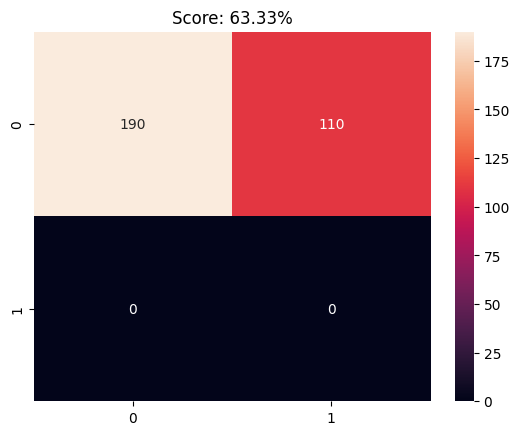

In [41]:
best_model = LAHT(vocab_size, embed_dim, hidden_dim, num_heads, red_size, out_classes)
best_model = best_model.to(device)
best_model.load_state_dict(torch.load("best_model.pt", weights_only=True))

def predict(text):

    txt = torch.tensor(encode(text), dtype=torch.long)
    txt = txt.view(1, txt.shape[0])

    best_model.eval()
    with torch.no_grad():
        if torch.cuda.is_available():
            txt = txt.cuda()
        out, _ = best_model(txt)

    index = out.argmax(1).item()

    return index, round(out[0][index].item()*100, 2)

truth = []
preds = []
probas = []

for i in range(x_test.shape[0]):
    truth += [y_test[i]]
    pred, proba = predict(x_test[i])
    preds += [pred]
    probas += [proba]

score = accuracy_score(preds, truth)
print(classification_report(preds, truth))
sns.heatmap(confusion_matrix(preds, truth), annot=True, fmt='d')
plt.title("Score: {}%".format(round(score*100, 2)))
plt.show()

# LAHT-Reverse

## LAHTRev training environment

In [42]:
model = LAHTRev(vocab_size, embed_dim, hidden_dim, num_heads, red_size, out_classes)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

## LAHTRev training log

Epoch 1 train loss 0.02042587288788387 acc 0.6914285714285714 val loss 0.018527666529019673 acc 0.8366666666666667
Epoch 2 train loss 0.01449995573077883 acc 0.9664285714285714 val loss 0.013093061943848927 acc 1.0
Epoch 3 train loss 0.011076070836612157 acc 0.9992857142857143 val loss 0.01097065140803655 acc 1.0
Epoch 4 train loss 0.01013765811920166 acc 1.0 val loss 0.010674120088418325 acc 1.0
Epoch 5 train loss 0.010009811648300716 acc 1.0 val loss 0.010584336916605631 acc 1.0
Epoch 6 train loss 0.009961294957569667 acc 1.0 val loss 0.010550584495067596 acc 1.0
Epoch 7 train loss 0.009933406114578247 acc 1.0 val loss 0.010525508721669515 acc 1.0
Epoch 8 train loss 0.009917127106870923 acc 1.0 val loss 0.010507071117560069 acc 1.0
Epoch 9 train loss 0.009902218069349017 acc 1.0 val loss 0.010497179329395295 acc 1.0
Epoch 10 train loss 0.009895318150520326 acc 1.0 val loss 0.010487939616044363 acc 1.0


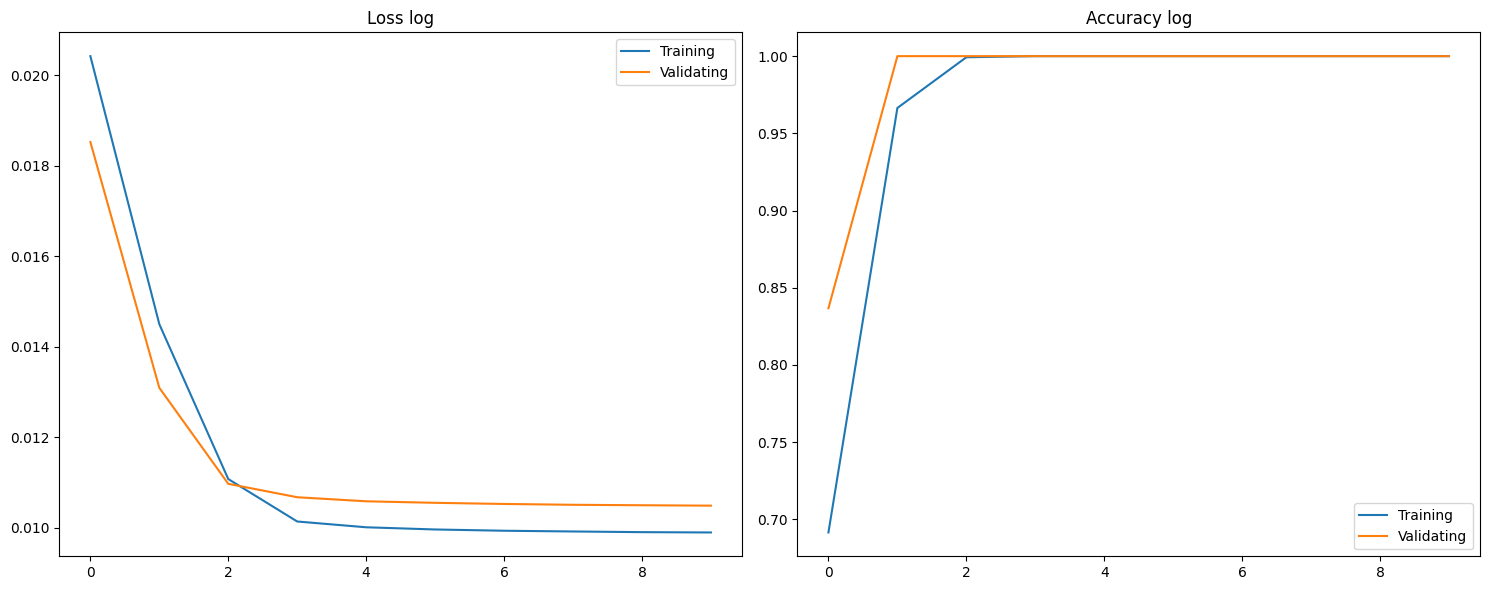

In [43]:
torch.save(model.state_dict(), "laht_best_model.pt")

# best_model = deepcopy(model)
best_acc = 0

train_loss = []
train_acc = []
val_loss = []
val_acc = []

for i in range(1, epochs+1):
    model.train()

    diff = 0
    acc = 0
    total = 0

    preds = []
    outs = []

    for data, target in train_dl:
        optimizer.zero_grad()
        if torch.cuda.is_available():
            data, target = data.cuda(), target.cuda()

        out, pred_anfis = model(data)
        preds += [pred_anfis]
        outs += [target]
        loss = criterion(out, target.type(torch.int64))
        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)

        loss.backward()
        optimizer.step()

    train_loss += [diff/total]
    train_acc += [acc/total]

    model.eval()

    diff = 0
    acc = 0
    total = 0

    with torch.no_grad():
        
        x_pred = torch.cat(preds)
        x_pred = x_pred.to(device)
        y_acc = torch.cat(outs).to(device)
        model.anfis.fit_coeff(x_pred, y_acc)
        
        for data, target in val_dl:
            optimizer.zero_grad()
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()

            out, _ = model(data)
            loss = criterion(out, target.type(torch.int64))
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)

    val_loss += [diff/total]
    val_acc += [acc/total]

    if val_acc[-1] >= best_acc:
        best_acc = val_acc[-1]
        torch.save(model.state_dict(), "laht_best_model.pt")

    # scheduler.step()

    print("Epoch {} train loss {} acc {} val loss {} acc {}".format(i, train_loss[-1], train_acc[-1],
                                                                   val_loss[-1], val_acc[-1]))

fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

index = 0

axes[index].plot(train_loss, label="Training")
axes[index].plot(val_loss, label="Validating")
axes[index].set_title("Loss log")
axes[index].legend()

index += 1

axes[index].plot(train_acc, label="Training")
axes[index].plot(val_acc, label="Validating")
axes[index].set_title("Accuracy log")
axes[index].legend()
plt.tight_layout()
plt.show()

## LAHTRev testing

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00       110

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



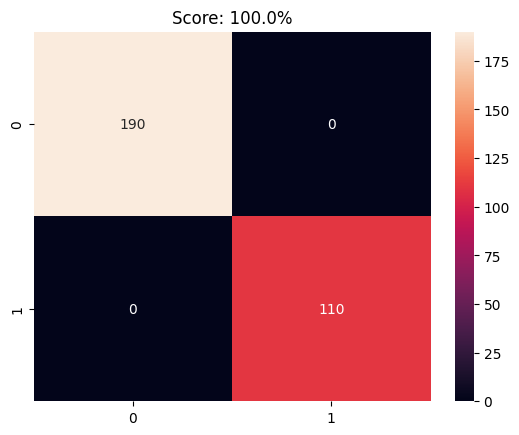

In [44]:
best_model = LAHTRev(vocab_size, embed_dim, hidden_dim, num_heads, red_size, out_classes)
best_model = best_model.to(device)
best_model.load_state_dict(torch.load("laht_best_model.pt", weights_only=True))

def predict(text):

    txt = torch.tensor(encode(text), dtype=torch.long)
    txt = txt.view(1, txt.shape[0])

    best_model.eval()
    with torch.no_grad():
        if torch.cuda.is_available():
            txt = txt.cuda()
        out, _ = best_model(txt)

    index = out.argmax(1).item()

    return index, round(out[0][index].item()*100, 2)

truth = []
preds = []
probas = []

for i in range(x_test.shape[0]):
    truth += [y_test[i]]
    pred, proba = predict(x_test[i])
    preds += [pred]
    probas += [proba]

score = accuracy_score(preds, truth)
print(classification_report(preds, truth))
sns.heatmap(confusion_matrix(preds, truth), annot=True, fmt='d')
plt.title("Score: {}%".format(round(score*100, 2)))
plt.show()